In [3]:
from dace_query.sun import Sun
import matplotlib.pyplot as plt
from astropy.io import fits
import os
import numpy as np
import jdcal as j 
from astropy.time import Time
from pathlib import Path

import pandas as pd

In [34]:
# All data
data_original = Sun.query_database(output_format="pandas")

sorted(data_original.columns.to_list())

# Remove some outliers that are more than 25 m/s away from the median
to_keep_raw = (
    np.abs(data_original.spectro_ccf_rv - np.median(data_original.spectro_ccf_rv)) < 25
)

# to_keep_corr = (
#     np.abs(data_original.spectro_ccf_rv_corr ) > 1e5
# )

masks = (data_original.spectro_analysis_qualflag > 0.999) * to_keep_raw
data = data_original[masks]

# Public data

data_public = pd.read_csv('/home/sophie-stucki/Documents/starsim_simulations/harpn_sun_release_timeseries_2015-2018/harpn_sun_release_timeseries_2015-2018.csv')
new_data_public = pd.read_csv('/home/sophie-stucki/Downloads/2015-2025/2015-2025/harpn_sun_release_timeseries_2015-2025.csv')

In [23]:
data.keys()

Index(['file_rootpath', 'obj_date_bjd', 'spectro_ccf_rv_corr',
       'spectro_analysis_rhk', 'spectro_analysis_diff_extinction',
       'spectro_flux_sn50', 'spectro_flux_sn10', 'spectro_flux_sn20',
       'spectro_flux_sn30', 'date_night', 'spectro_ccf_contrast_corr',
       'spectro_ccf_contrast_err', 'spectro_ccf_rv_err', 'spectro_flux_sn60',
       'spectro_cal_berv', 'spectro_ccf_fwhm',
       'spectro_analysis_berv_helio_bary', 'spectro_analysis_smw',
       'spectro_ccf_bispan_err', 'spectro_analysis_smw_err',
       'spectro_analysis_rhk_err', 'spectro_ccf_fwhm_corr',
       'spectro_ccf_fwhm_err', 'spectro_ccf_rv', 'spectro_ccf_contrast',
       'spectro_ccf_bispan', 'spectro_drs_qc', 'spectro_flux_sn40', 'texp',
       'spectro_analysis_qualflag', 'status_public', 'ins_name', 'program_id'],
      dtype='object')

In [35]:
new_data_public.keys()

Index(['file_root', 'night', 'bjd', 'alpha', 'delta', 'texp', 'airmass',
       'photocenter', 'sn_order_20', 'sn_order_50', 'sn_order_60',
       'obs_quality', 'data_quality', 'rv_raw', 'rv', 'rv_err', 'rhk',
       'rhk_err', 'smw', 'smw_err', 'mg2', 'bis_span_raw', 'bis_span',
       'bis_span_err', 'fwhm_raw', 'fwhm', 'fwhm_err', 'contrast_raw',
       'contrast', 'contrast_err', 'berv', 'berv_bary_to_helio',
       'rv_diff_extinction', 'rv_optimised_corr'],
      dtype='object')

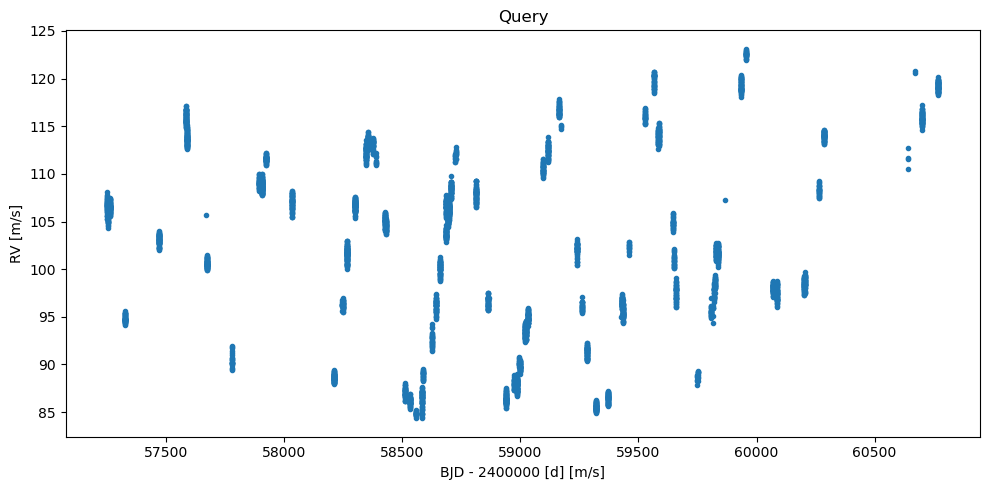

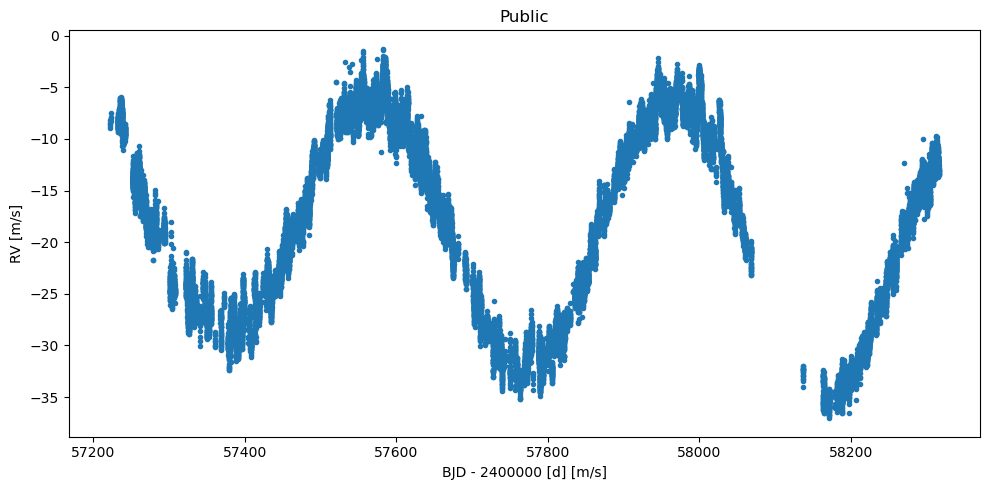

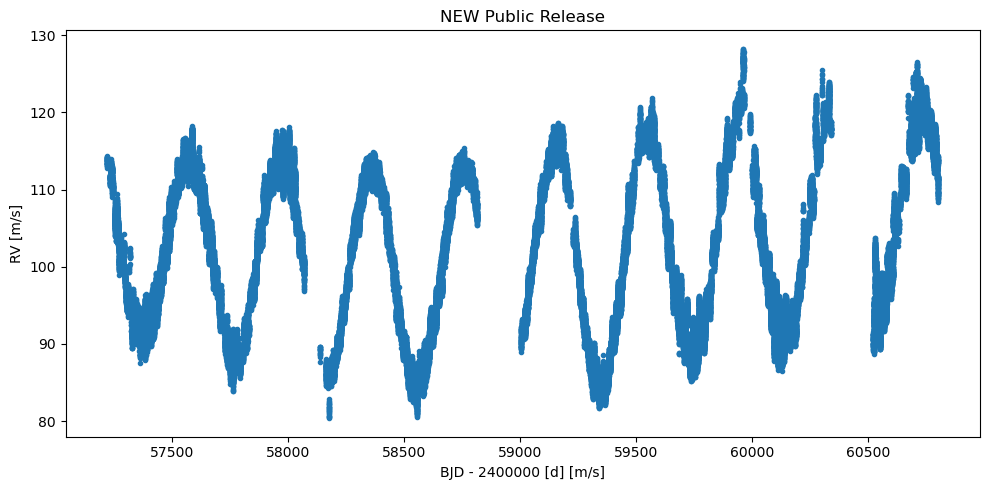

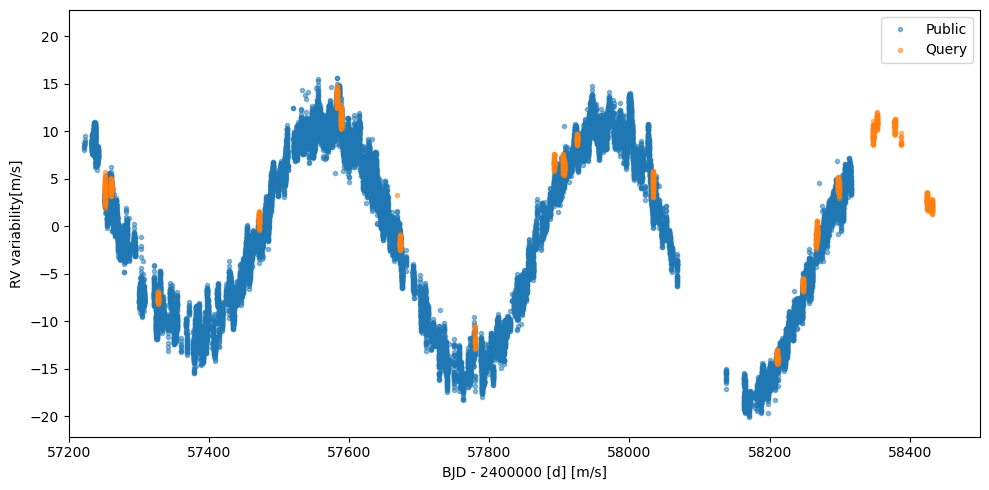

In [38]:
# Plot the raw radial velocities, in the Solar System barycenter rest frame
plt.figure(figsize=(10, 5))
plt.plot(data.obj_date_bjd, data.spectro_ccf_rv, ".")
plt.xlabel("BJD - 2400000 [d] [m/s]")
plt.ylabel("RV [m/s]")
plt.title('Query')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(data_public.date_bjd, data_public.rv_raw, ".")
plt.xlabel("BJD - 2400000 [d] [m/s]")
plt.ylabel("RV [m/s]")
plt.title('Public')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(new_data_public.bjd, new_data_public.rv_raw * 1e3, ".")
plt.xlabel("BJD - 2400000 [d] [m/s]")
plt.ylabel("RV [m/s]")
plt.title('NEW Public Release')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(data_public.date_bjd, data_public.rv_raw - np.mean(data_public.rv_raw), ".", alpha = 0.5, label='Public')
plt.plot(data.obj_date_bjd, data.spectro_ccf_rv - np.mean(data.spectro_ccf_rv), ".", alpha = 0.5, label='Query')
plt.xlabel("BJD - 2400000 [d] [m/s]")
plt.ylabel("RV variability[m/s]")
plt.xlim(57200, 58500)
plt.tight_layout()
plt.legend()

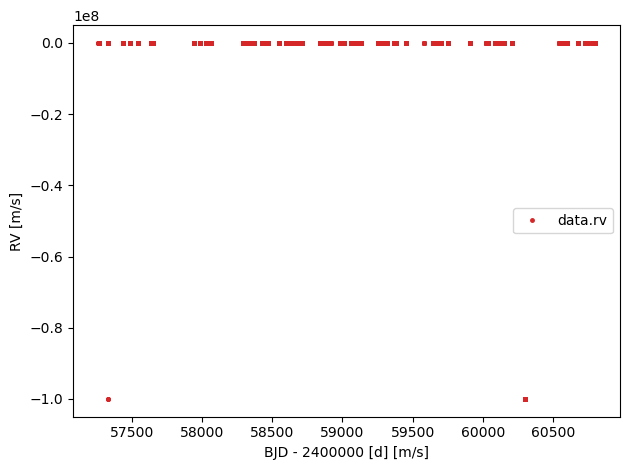

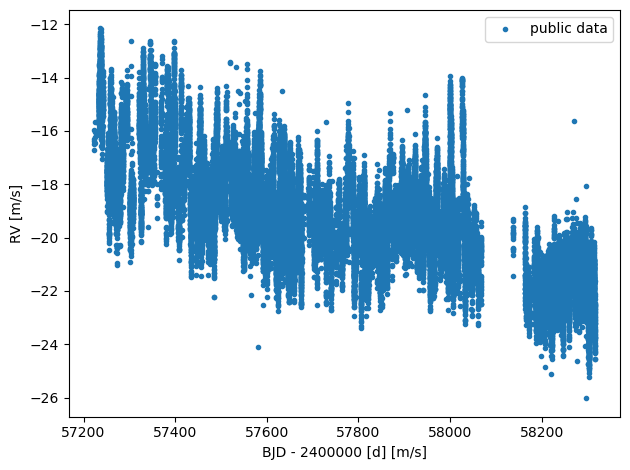

In [19]:
plt.plot(
    data.obj_date_bjd,
    data.spectro_ccf_rv_corr,
    marker=".",
    ls="",
    ms=5,
    color="C3",
    label="data.rv",
)
plt.legend()
plt.xlabel("BJD - 2400000 [d] [m/s]")
plt.ylabel("RV [m/s]")
# plt.ylim(-7,15)
# plt.xlim(57400, 57500)
plt.tight_layout()

plt.show()


plt.plot(data_public.date_bjd, data_public.rv, '.', label='public data')
plt.legend()
plt.xlabel("BJD - 2400000 [d] [m/s]")
plt.ylabel("RV [m/s]")
plt.tight_layout()

plt.show()

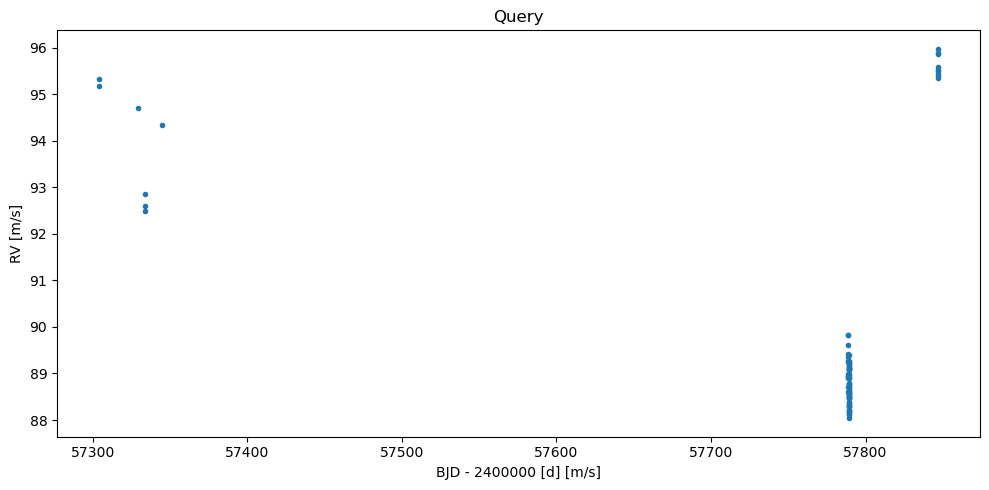

In [26]:
masks_off = np.abs(data.spectro_ccf_rv_corr)>1e7

plt.figure(figsize=(10, 5))
plt.plot(data.obj_date_bjd[masks_off], data.spectro_ccf_rv[masks_off], ".")
plt.xlabel("BJD - 2400000 [d] [m/s]")
plt.ylabel("RV [m/s]")
plt.title('Query')
plt.tight_layout()
plt.show()

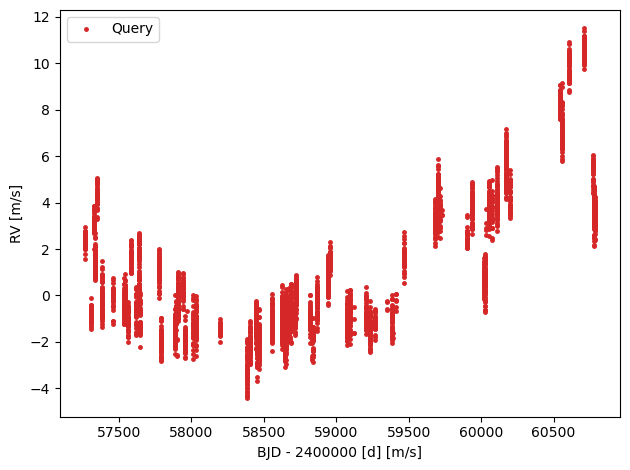

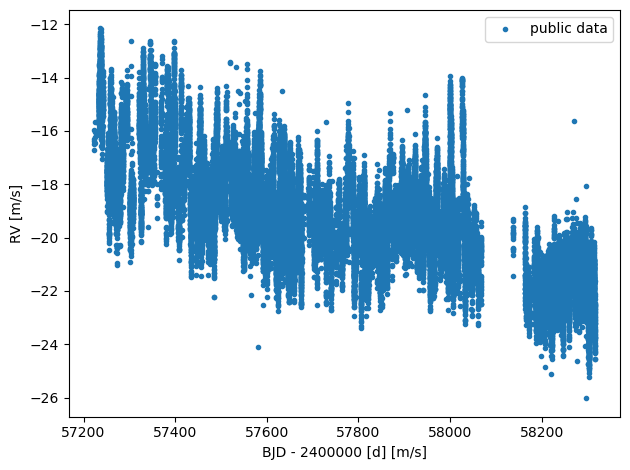

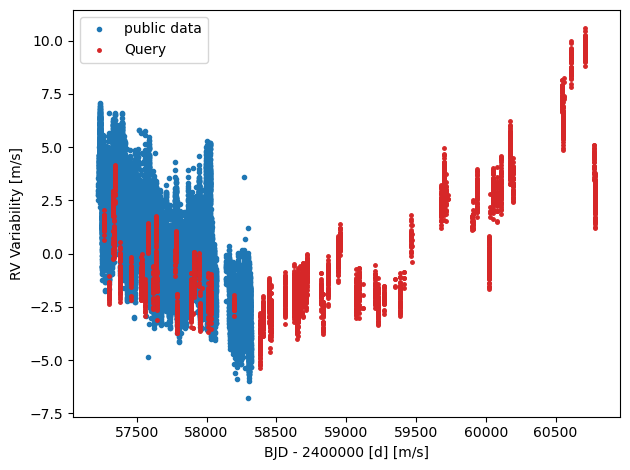

In [32]:
plt.plot(
    data.obj_date_bjd[~masks_off],
    data.spectro_ccf_rv_corr[~masks_off],
    marker=".",
    ls="",
    ms=5,
    color="C3",
    label="Query",
)
plt.legend()
plt.xlabel("BJD - 2400000 [d] [m/s]")
plt.ylabel("RV [m/s]")
# plt.ylim(-7,15)
# plt.xlim(57400, 57500)
plt.tight_layout()

plt.show()


plt.plot(data_public.date_bjd, data_public.rv, '.', label='public data')
plt.legend()
plt.xlabel("BJD - 2400000 [d] [m/s]")
plt.ylabel("RV [m/s]")
plt.tight_layout()

plt.show()

plt.plot(data_public.date_bjd, data_public.rv-np.mean(data_public.rv), '.', label='public data')

plt.plot(
    data.obj_date_bjd[~masks_off],
    data.spectro_ccf_rv_corr[~masks_off]-np.mean(data.spectro_ccf_rv_corr[~masks_off]),
    marker=".",
    ls="",
    ms=5,
    color="C3",
    label="Query",
)
plt.legend()
plt.xlabel("BJD - 2400000 [d] [m/s]")
plt.ylabel("RV Variability [m/s]")
plt.tight_layout()

plt.show()

In [33]:
data.status_public[~masks_off]

1       True
3       True
4       True
5       True
6       True
        ... 
9994    True
9995    True
9996    True
9998    True
9999    True
Name: status_public, Length: 3929, dtype: bool